
$\phi^3$: $\phi\phi \to n\,\phi$
  n_final=2:  t_BG = 2.2562e-05 ± 2.0487e-06 s   |  N_diagrams = 3
  n_final=3:  t_BG = 7.0156e-05 ± 2.8942e-06 s   |  N_diagrams = 15
  n_final=4:  t_BG = 2.0542e-04 ± 7.6618e-06 s   |  N_diagrams = 105
  n_final=5:  t_BG = 5.7319e-04 ± 1.3400e-05 s   |  N_diagrams = 945
  n_final=6:  t_BG = 1.6497e-03 ± 5.7804e-05 s   |  N_diagrams = 10395
  n_final=7:  t_BG = 4.5491e-03 ± 6.2732e-05 s   |  N_diagrams = 135135
  n_final=8:  t_BG = 1.3438e-02 ± 2.8672e-04 s   |  N_diagrams = 2027025

Yukawa: $\psi\bar\psi \to n\,\phi$
  n_final=2:  t_BG = 2.6781e-04 ± 4.2769e-06 s   |  N_diagrams = 2
  n_final=3:  t_BG = 8.2449e-04 ± 2.2030e-05 s   |  N_diagrams = 6
  n_final=4:  t_BG = 2.0896e-03 ± 2.9307e-05 s   |  N_diagrams = 24
  n_final=5:  t_BG = 5.5271e-03 ± 1.8694e-04 s   |  N_diagrams = 120
  n_final=6:  t_BG = 1.2771e-02 ± 1.9070e-04 s   |  N_diagrams = 720
  n_final=7:  t_BG = 3.1949e-02 ± 7.9919e-04 s   |  N_diagrams = 5040
  n_final=8:  t_BG = 7.5532e-02

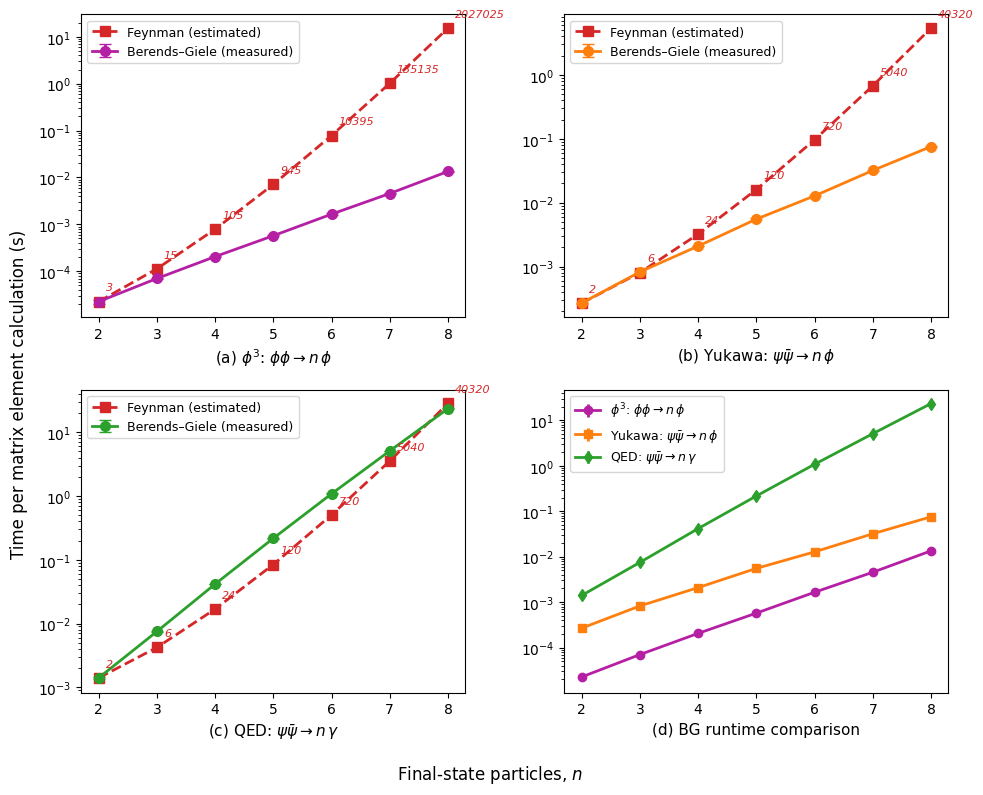


Theory       n     N_diag     t_BG (s)  t_Feynman (s)    Ratio
-----------------------------------------------------------------
phi          2          3   2.2562e-05     2.2562e-05      1.0x
phi          3         15   7.0156e-05     1.1281e-04      1.6x
phi          4        105   2.0542e-04     7.8969e-04      3.8x
phi          5        945   5.7319e-04     7.1072e-03     12.4x
phi          6      10395   1.6497e-03     7.8179e-02     47.4x
phi          7     135135   4.5491e-03     1.0163e+00    223.4x
phi          8    2027025   1.3438e-02     1.5245e+01   1134.5x

yukawa       2          2   2.6781e-04     2.6781e-04      1.0x
yukawa       3          6   8.2449e-04     8.0344e-04      1.0x
yukawa       4         24   2.0896e-03     3.2138e-03      1.5x
yukawa       5        120   5.5271e-03     1.6069e-02      2.9x
yukawa       6        720   1.2771e-02     9.6413e-02      7.5x
yukawa       7       5040   3.1949e-02     6.7489e-01     21.1x
yukawa       8      40320   7.5532e-0

In [2]:
"""
Benchmark: Berends–Giele recursion vs expected Feynman-diagram scaling.

For each theory, measures the wall-clock time of the matrix-element
calculation (BG recursion) as a function of n_final, and compares it
against the expected Feynman-diagram cost:

    t_Feynman(n) = t_BG(n_min) × N_diagrams(n) / N_diagrams(n_min)

This normalises at n_final = 2 (where BG and Feynman do comparable
work) and extrapolates via the diagram-count ratio alone — which is
conservative, since the per-diagram cost also grows with n.

Diagram counting:
  φ³    :  (2 n_total - 5)!!   tree topologies  (n_total = n_final + 2)
  Yukawa:  n_final!            orderings of φ emissions on the ψ line
  QED   :  n_final!            orderings of γ emissions on the ψ line

Phase-space points are generated via RAMBO *before* timing begins.
Only the matrix-element function call is timed.
"""

import time
import math
import numpy as np
import matplotlib.pyplot as plt
import mc_integration as mc

from currents_phi import calculate_matrix_element as phi_me
from currents_yukawa import (FieldType as YFT,
                             spin_averaged_matrix_element as yukawa_me)
from currents_qed_v2 import (FieldType as QFT,
                             spin_averaged_matrix_element as qed_me)

# ── Parameters (all couplings = 1 for a clean algorithmic benchmark) ──
if False: # Old parameters
    com_energy  = 5000.0
    vev         = 246.21965
    fine        = 137.035999084

    m_phi       = 125.2
    masses_psi  = {"electron": 0.00051099895, "muon": 0.1057583755, "tau": 1.77693}

    g           = np.sqrt(2)*masses_psi["electron"]/vev
    e           = np.sqrt(4 * np.pi / fine)
    lambda_0    = g
if True: # New parameters for a cleaner benchmark
    com_energy  = 100.0
    vev         = 246.21965
    f_s_constant= 137.035999084

    m_higgs     = 125.2

    # Explicitly used couplings and masses for the three theories:
    m_phi       = 5     #arbitrary light scalar mass for φ³ and Yukawa theories
    m_psi_benchmark = 5 # benchmark fermion mass for Yukawa coupling and QED (e.g. electron mass)
    masses_psi  = {"electron": m_psi_benchmark}
    #masses_psi  = {"electron": 0.00051099895, "muon": 0.1057583755, "tau": 1.77693}

    e           = np.sqrt(4 * np.pi / f_s_constant)
    g           = e
    lambda_0    = e # match QED strength

n_final_list = [2, 3, 4, 5, 6, 7, 8]

# Adaptive sample counts: fast low-n calls need more samples for
# stable averages; slow high-n calls need fewer.
n_samples = {2: 200, 3: 100, 4: 50, 5: 20, 6: 10, 7: 5, 8: 5}


# ── Diagram counting ─────────────────────────────────────────────────
def double_factorial(n):
    """n!! = n × (n-2) × (n-4) × ... × 1 (or 2)."""
    result = 1
    while n > 0:
        result *= n
        n -= 2
    return result


def phi3_n_diagrams(n_final):
    return double_factorial(2 * n_final - 1)      # (2n-1)!!


def yukawa_n_diagrams(n_final):
    return math.factorial(n_final)                 # n!


def qed_n_diagrams(n_final):
    return math.factorial(n_final)                 # n!


# ── Phase-space generation (NOT timed) ───────────────────────────────
def generate_events(n_final, theory):
    if theory == "phi":
        masses = np.array([m_phi] * (n_final + 2))
    elif theory == "yukawa":
        masses = np.array([masses_psi["electron"], masses_psi["electron"]] + [m_phi] * n_final)
    elif theory == "qed":
        masses = np.array([masses_psi["electron"], masses_psi["electron"]] + [0.0] * n_final)

    masses_in, masses_out, n_out = mc.separate_in_and_out(
        n_final + 2, masses)

    events = []
    for _ in range(n_samples[n_final]):
        p_in  = mc.incoming_momenta(com_energy, masses_in)
        p_out, _ = mc.generate_phase_space(com_energy, n_out, masses_out)
        events.append(np.vstack((*p_in, p_out)))
    return events


# ── Pre-build particle lists for Yukawa / QED (NOT timed) ───────────
def build_yukawa_pts(p_event, n_final):
    n_particles = n_final + 2
    ft = [YFT.PSI, YFT.PSIBAR] + [YFT.PHI] * n_final
    fl = ["electron", "electron"] + [None] * n_final
    pts = [{"type": ft[0], "p": p_event[0],
            "incoming": True,  "flavour": fl[0]},
           {"type": ft[1], "p": p_event[1],
            "incoming": True,  "flavour": fl[1]}]
    for j in range(2, n_particles):
        pts.append({"type": ft[j], "p": p_event[j],
                     "incoming": False, "flavour": fl[j]})
    return pts


def build_qed_pts(p_event, n_final):
    n_particles = n_final + 2
    ft = [QFT.PSI, QFT.PSIBAR] + [QFT.A] * n_final
    fl = ["electron", "electron"] + [None] * n_final
    pts = [{"type": ft[0], "p": p_event[0],
            "incoming": True,  "flavour": fl[0]},
           {"type": ft[1], "p": p_event[1],
            "incoming": True,  "flavour": fl[1]}]
    for j in range(2, n_particles):
        pts.append({"type": ft[j], "p": p_event[j],
                     "incoming": False, "flavour": fl[j]})
    return pts


# ── Time matrix-element calls only ──────────────────────────────────
def time_bg(n_final, theory):
    """Return (mean_time, stderr_time) in seconds for one ME evaluation."""
    events = generate_events(n_final, theory)

    # Pre-build particle lists outside the clock
    if theory == "yukawa":
        pts_list = [build_yukawa_pts(ev, n_final) for ev in events]
    elif theory == "qed":
        pts_list = [build_qed_pts(ev, n_final) for ev in events]

    times = []
    masses_psi_dict = masses_psi

    for i, ev in enumerate(events):
        if theory == "phi":
            t0 = time.perf_counter()
            phi_me(ev, m_phi, lambda_0)
            t1 = time.perf_counter()

        elif theory == "yukawa":
            pts = pts_list[i]
            t0 = time.perf_counter()
            yukawa_me(pts, m_phi, masses_psi_dict, g)
            t1 = time.perf_counter()

        elif theory == "qed":
            pts = pts_list[i]
            t0 = time.perf_counter()
            qed_me(pts, masses_psi_dict, e)
            t1 = time.perf_counter()

        times.append(t1 - t0)

    arr = np.array(times)
    return arr.mean(), arr.std(ddof=1) / np.sqrt(len(arr))


# ── Run benchmarks ──────────────────────────────────────────────────

def yukawa_spin_factor(n_final):
    return 4   # 2 spins × 2 spins (initial only)

def qed_spin_factor(n_final):
    return 2**(n_final + 2)  # 2^2 (initial fermions) × 2^n (photons)

def phi_spin_factor(n_final):
    return 1   # scalars

theories = [
    {"name": "phi",    "label": r"$\phi^3$: $\phi\phi \to n\,\phi$",
     "n_diag": phi3_n_diagrams,
     "spin_factor": phi_spin_factor},
    {"name": "yukawa", "label": r"Yukawa: $\psi\bar\psi \to n\,\phi$",
     "n_diag": yukawa_n_diagrams,
     "spin_factor": yukawa_spin_factor},
    {"name": "qed",    "label": r"QED: $\psi\bar\psi \to n\,\gamma$",
     "n_diag": qed_n_diagrams,
     "spin_factor": qed_spin_factor},
]

results = {}
for th in theories:
    name = th["name"]
    results[name] = {"bg_mean": [], "bg_err": [], "n_diag": []}
    print(f"\n{'='*50}\n{th['label']}\n{'='*50}")
    for n in n_final_list:
        nd = th["n_diag"](n)
        mean, err = time_bg(n, name)
        results[name]["bg_mean"].append(mean)
        results[name]["bg_err"].append(err)
        results[name]["n_diag"].append(nd)
        print(f"  n_final={n}:  t_BG = {mean:.4e} ± {err:.4e} s"
              f"   |  N_diagrams = {nd}")



# ── Expected Feynman scaling ────────────────────────────────────────
for name in results:
    r = results[name]
    t0   = r["bg_mean"][0]
    nd0  = r["n_diag"][0]
    sf = th["spin_factor"]
    sf0 = sf(n_final_list[0])
    r["feynman_expected"] = [
        t0 * nd / nd0 for nd in r["n_diag"]]

    r["feynman_spin_expected"] = [
        t0 * (nd * sf(n)) / (nd0 * sf0)
        for n, nd in zip(n_final_list, r["n_diag"])]


# ── Plot: 2×2 grid ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
fig.supxlabel(r'Final-state particles, $n$', fontsize = 12)
fig.supylabel('Time per matrix element calculation (s)', fontsize=12)

colours_bg  = ["#b41fa3", '#ff7f0e', '#2ca02c']
colours_fd  = ['#aec7e8', '#ffbb78', '#98df8a']

panel_titles = [
    r"(a) $\phi^3$: $\phi\phi \to n\,\phi$",
    r"(b) Yukawa: $\psi\bar\psi \to n\,\phi$",
    r"(c) QED: $\psi\bar\psi \to n\,\gamma$",
    r"(d) All theories"]

for j, (ax, th, c_bg, c_fd) in enumerate(zip(axes[:3], theories, colours_bg, colours_fd)):
    name = th["name"]
    r    = results[name]
    n_arr = np.array(n_final_list)

    # BG measured
    ax.errorbar(n_arr, r["bg_mean"], yerr=r["bg_err"],
                fmt='o-', capsize=4, markersize=7, linewidth=2,
                color=c_bg, label='Berends–Giele (measured)')

    # Feynman expected
    ax.plot(n_arr, r["feynman_expected"],
            's--', markersize=7, linewidth=2,
            color='#d62728', label='Feynman (estimated)')
    
    #if th["name"] != "phi":
    #    ax.plot(n_arr, r["feynman_spin_expected"],
    #            'd-.', markersize=6, linewidth=2,
    #            color='#9467bd', label='Feynman + spin factors (estimated)')

    for i, n in enumerate(n_final_list):
        nd = r["n_diag"][i]
        ax.annotate(f'{nd}',
                    xy=(n, r["feynman_expected"][i]),
                    xytext=(5, 8), textcoords='offset points',
                    fontsize=8, color='#d62728', fontstyle='italic')

    ax.set_yscale('log')
    ax.set_xticks(n_final_list)
    ax.set_xlabel(panel_titles[j], fontsize=11)
    ax.legend(fontsize=9, loc='upper left')

# ── 4th plot: combined BG runtimes ────────────────────────────────
ax = axes[3]

markers = ['o', 's', 'd']

for th, color, m in zip(theories, colours_bg, markers):
    name = th["name"]
    r = results[name]

    ax.errorbar(n_final_list,
                r["bg_mean"],
                yerr=r["bg_err"],
                fmt=f'{m}-',
                linewidth=2,
                markersize=6,
                label=th["label"],
                color=color)
ax.set_xlabel('(d) BG runtime comparison', fontsize=11)
ax.set_yscale('log')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('bg_vs_feynman_timing_new.png', dpi=150, bbox_inches='tight')
print("\nPlot saved to bg_vs_feynman_timing_new.png")
plt.show()


# ── Print summary table ────────────────────────────────────────────
print(f"\n{'Theory':<10} {'n':>3} {'N_diag':>10} {'t_BG (s)':>12} "
      f"{'t_Feynman (s)':>14} {'Ratio':>8}")
print("-" * 65)
for th in theories:
    name = th["name"]
    r = results[name]
    for i, n in enumerate(n_final_list):
        ratio = r["feynman_expected"][i] / r["bg_mean"][i]
        print(f"{name:<10} {n:>3} {r['n_diag'][i]:>10} "
              f"{r['bg_mean'][i]:>12.4e} "
              f"{r['feynman_expected'][i]:>14.4e} "
              f"{ratio:>8.1f}x")
    print()